In [50]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torchvision.ops import masks_to_boxes
from torchvision.transforms.functional import normalize

In [58]:
im_path = "/data/datasets/nii/MSD/Task02_Heart/imagesTr/la_003.nii.gz"
gt_path = "/data/datasets/nii/MSD/Task02_Heart/labelsTr/la_003.nii.gz"
im = nib.load(im_path).get_fdata()
gt = nib.load(gt_path).get_fdata()

In [59]:
im = torch.rot90(torch.tensor(im)).permute(2, 0, 1).unsqueeze(0).unsqueeze(0)
gt = torch.rot90(torch.tensor(gt)).permute(2, 0, 1).unsqueeze(0).unsqueeze(0)

# im = F.interpolate(im, size=(im.shape[2], 1024, 1024), mode='trilinear', align_corners=False)
gt = F.interpolate(gt, size=(gt.shape[2], 1024, 1024), mode='nearest')
im = im.squeeze(0).repeat(3, 1, 1, 1).permute(1, 0, 2, 3)
gt = gt.squeeze(0).squeeze(0)

# im = normalize(im, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

In [60]:
im = (im - im.min()) / (im.max() - im.min())

In [61]:
im.shape, gt.shape

(torch.Size([130, 3, 320, 320]), torch.Size([130, 1024, 1024]))

In [62]:
np.argwhere(gt.sum(axis=(0, 1))).squeeze()

tensor([368, 369, 370, 371, 372, 373, 374, 375, 376, 377, 378, 379, 380, 381,
        382, 383, 384, 385, 386, 387, 388, 389, 390, 391, 392, 393, 394, 395,
        396, 397, 398, 399, 400, 401, 402, 403, 404, 405, 406, 407, 408, 409,
        410, 411, 412, 413, 414, 415, 416, 417, 418, 419, 420, 421, 422, 423,
        424, 425, 426, 427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437,
        438, 439, 440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450, 451,
        452, 453, 454, 455, 456, 457, 458, 459, 460, 461, 462, 463, 464, 465,
        466, 467, 468, 469, 470, 471, 472, 473, 474, 475, 476, 477, 478, 479,
        480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490, 491, 492, 493,
        494, 495, 496, 497, 498, 499, 500, 501, 502, 503, 504, 505, 506, 507,
        508, 509, 510, 511])

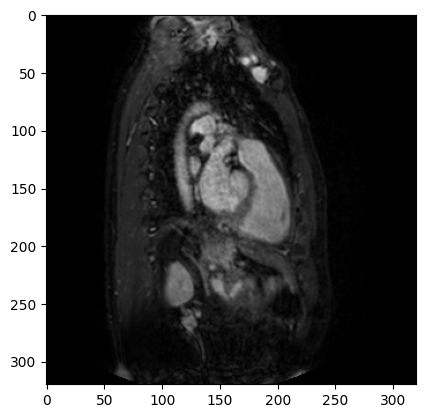

In [63]:
plt.imshow(im[60].permute(1,2,0), cmap="grey")
# plt.imshow(gt[60], alpha=0.4, cmap="jet")